## Diffusion for image transformation
***
In this notebook, we utilize a Conditional Denoising Diffusion Probabilistic Model (DDPM) to perform image-to-image translation between cats and dogs.

Unlike GANs which learn a direct mapping between domains, we employ an iterative refinement process known as SDEdit. To translate an image (e.g., from Cat to Dog), we first diffuse the source image by adding Gaussian noise until the fine class-specific details are destroyed, preserving only the coarse structure. We then reverse the diffusion process, conditioning the U-Net on the target class label (Dog) to hallucinate the new textures and features onto the original geometry.

### 1. Dataset loaders
Unlike the CycleGAN implementation which required splitting the data by domain (Folder A for Cats, Folder B for Dogs), we organize our data into standard Training and Validation sets.

The loaders below provide mixed batches of images and their corresponding class labels (Cat=0, Dog=1). This supervised structure allows the model to learn a conditional distribution p(x∣y), effectively learning to generate both species within a single network by using the label as a control switch. The validation set is kept separate to monitor the reconstruction loss and ensure the model does not memorize the training data.

In [1]:
import os
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

IMG_SIZE=64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scale to [-1, 1]
    ])


def get_dataloaders(data_dir, batch_size=24, shuffle=True, transform=transform):
    """Larger batch size now that we have memory"""
    # Load the full dataset
    full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    g = torch.Generator()
    g.manual_seed(42)
    # Filter for only Cats (label 0) and Dogs (label 1) 
    indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label in [0, 1]]
    cat_dog_dataset = Subset(full_dataset, indices)
    
    loader = DataLoader(cat_dog_dataset, batch_size=batch_size, shuffle=shuffle, num_workers=2, generator=g)
    return loader, full_dataset.classes

Using device: cuda


In [2]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(dataloader, classes):
    images, labels = next(iter(dataloader))
    
    # Un-normalize for visualization
    images = images * 0.5 + 0.5 
    
    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        plt.title(f"Label: {classes[labels[i]]}")
        plt.axis('off')
    plt.show()

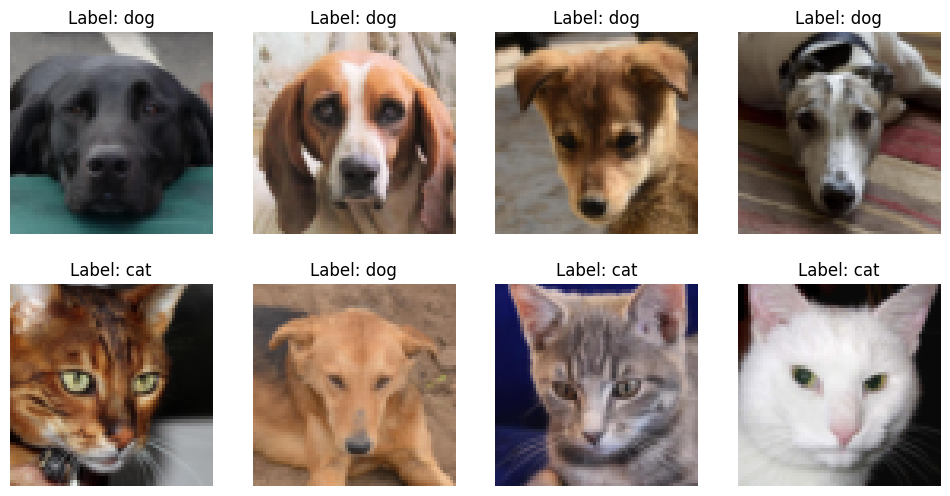

In [3]:
# Setup
train_loader, train_classes = get_dataloaders("./afhq/train")
show_batch(train_loader, train_classes)

### 2. Diffusion Model Definition
The following code represents the definition of the Conditional Diffusion model to be trained. The framework consists of a U-Net backbone for noise prediction and a utility class for managing the diffusion process.

1. Conditional U-Net: This network predicts the noise residual in the image. It uses a contracting path (Encoder) with 3 levels of downsampling via MaxPool and a symmetric expanding path (Decoder) using bilinear upsampling.

    - Conditioning: Unlike standard U-Nets, it injects Time and CLIP embeddings into every layer using Adaptive Instance Normalization (AdaIN/FiLM). This modulates the feature statistics (mean and variance) based on the target class and current noise level.

    - Blocks: It utilizes DoubleConv blocks consisting of 2D Convolutions, Group Normalization, and GELU activations.

    - Self-Attention: To improve global coherence (e.g., ensuring eyes and facial structures align), Self-Attention layers are integrated at the lowest resolutions (128 channels).

2. EMA (Exponential Moving Average): A wrapper class that maintains a moving average of the model weights during training. This stabilizes the training dynamics and often yields higher-quality generations than the raw model weights.

3. Diffusion Process: This class manages the stochastic elements. It implements a Cosine Beta Schedule to control the noise variance βt​ over 1000 steps and contains the img2img sampling loop which performs the iterative denoising required for the image-to-image translation task.

In [103]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import copy

class EMA:
    def __init__(self, model, decay=0.9999):
        self.decay = decay
        self.ema_model = copy.deepcopy(model)
        self.ema_model.eval()  # EMA model is only used for inference
        # Disable gradients for EMA
        for p in self.ema_model.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        # Update EMA weights
        for ema_p, model_p in zip(self.ema_model.parameters(), model.parameters()):
            ema_p.data.mul_(self.decay).add_(model_p.data, alpha=1 - self.decay)

class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(min(32, channels), channels)
        self.q = nn.Conv2d(channels, channels, 1)
        self.k = nn.Conv2d(channels, channels, 1)
        self.v = nn.Conv2d(channels, channels, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        b, c, h, w = x.shape

        x_norm = self.norm(x)
        q = self.q(x_norm).reshape(b, c, h * w)
        k = self.k(x_norm).reshape(b, c, h * w)
        v = self.v(x_norm).reshape(b, c, h * w)

        attn = torch.softmax(
            torch.bmm(q.transpose(1, 2), k) / math.sqrt(c),
            dim=-1
        )

        out = torch.bmm(v, attn.transpose(1, 2))
        out = out.reshape(b, c, h, w)

        return x + self.proj(out)

class ConditionalUNet(nn.Module):
    def __init__(self, c_in=3, c_out=3, time_dim=64, clip_dim=512, device="cuda"):
        super().__init__()
        self.device = device
        self.time_dim = time_dim
        
        # Time Embedding
        self.time_emb = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )
        
        # CLIP Embedding projection (512 -> time_dim)
        self.clip_proj = nn.Sequential(
            nn.Linear(clip_dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )
        self.cond_proj = nn.Linear(time_dim * 2, time_dim)
        
        # Feature-wise modulation layers
        self.ada_gamma_32 = nn.Linear(time_dim, 32)
        self.ada_beta_32 = nn.Linear(time_dim, 32)
        self.ada_gamma_64 = nn.Linear(time_dim, 64)
        self.ada_beta_64 = nn.Linear(time_dim, 64)
        self.ada_gamma_128 = nn.Linear(time_dim, 128)
        self.ada_beta_128 = nn.Linear(time_dim, 128)
        
        # Downsampling - 3 levels
        self.inc = DoubleConv(c_in, 32)
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 128)
        
        # Upsampling
        self.up1 = Up(256, 64)
        self.up2 = Up(128, 32)
        self.up3 = Up(64, 32)
        
        self.attn3 = SelfAttention(128)
        self.attn4 = SelfAttention(128)

        self.outc = nn.Conv2d(32, c_out, kernel_size=1)

    def forward(self, x, t, clip_emb):
        t = t.unsqueeze(-1).type(torch.float)
        t_emb = self.time_emb(t)
        
        clip_cond = self.clip_proj(clip_emb)
        
        # Merge time + clip conditioning
        cond = torch.cat([t_emb, clip_cond], dim=1)
        cond = self.cond_proj(cond)

        # Encoder
        x1 = self.inc(x)
        x1 = self.ada_in(x1, cond, 32)
        
        x2 = self.down1(x1)
        x2 = self.ada_in(x2, cond, 64)
        
        x3 = self.down2(x2)
        x3 = self.ada_in(x3, cond, 128)
        x3 = self.attn3(x3)
        
        x4 = self.down3(x3)
        x4 = self.ada_in(x4, cond, 128)
        x4 = self.attn4(x4)

        # Decoder
        x = self.up1(x4, x3)
        x = self.ada_in(x, cond, 64)
        
        x = self.up2(x, x2)
        x = self.ada_in(x, cond, 32)
        
        x = self.up3(x, x1)
        
        return self.outc(x)
    
    def ada_in(self, x, cond, channels):
        """Adaptive Instance Normalization with proper FiLM modulation"""
        B, C, H, W = x.shape
        
        # Instance normalization
        mean = x.mean(dim=[2, 3], keepdim=True)
        std = x.std(dim=[2, 3], keepdim=True) + 1e-5
        x_norm = (x - mean) / std
        
        # Get FiLM parameters: gamma and beta
        if channels == 32:
            gamma = self.ada_gamma_32(cond).view(B, 32, 1, 1)
            beta = self.ada_beta_32(cond).view(B, 32, 1, 1)
        elif channels == 64:
            gamma = self.ada_gamma_64(cond).view(B, 64, 1, 1)
            beta = self.ada_beta_64(cond).view(B, 64, 1, 1)
        elif channels == 128:
            gamma = self.ada_gamma_128(cond).view(B, 128, 1, 1)
            beta = self.ada_beta_128(cond).view(B, 128, 1, 1)
        else:
            gamma = torch.ones(B, C, 1, 1, device=x.device)
            beta = torch.zeros(B, C, 1, 1, device=x.device)
        
        # FiLM modulation: y = gamma * x_norm + beta
        return gamma * x_norm + beta

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), 
            nn.GroupNorm(32, out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), 
            nn.GroupNorm(32, out_ch), 
            nn.GELU(),
        )
    def forward(self, x): 
        return self.conv(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.mpconv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x): 
        return self.mpconv(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [0, diffX, 0, diffY])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class Diffusion:
    def __init__(self, noise_steps=1000, img_size=64, device="cuda", schedule="cosine"):
        self.noise_steps = noise_steps
        self.img_size = img_size
        self.device = device
        
        if schedule == "cosine":
            self.beta = self.cosine_beta_schedule(noise_steps).to(device)
        else:
            self.beta = torch.linspace(1e-4, 0.02, noise_steps).to(device)
        
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def cosine_beta_schedule(self, timesteps, s=0.008):
        """Cosine schedule"""
        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def noise_images(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        epsilon = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * epsilon, epsilon

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.noise_steps, size=(n,)).to(self.device)

    def img2img(self, model, image, target_label, clip_embeddings, start_step=500):
        """Translate image with CLIP conditioning"""
        model.eval()
        n = image.shape[0]
        
        t_start = torch.full((n,), start_step, device=self.device, dtype=torch.long)
        x, _ = self.noise_images(image, t_start)
        
        target_clip_emb = clip_embeddings[target_label].unsqueeze(0).expand(n, -1)
        
        with torch.no_grad():
            for i in reversed(range(1, start_step)):
                t = torch.ones(n) * i
                t = t.long().to(self.device)
                
                predicted_noise = model(x, t, target_clip_emb)
                
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                
                noise = torch.randn_like(x) if i > 1 else torch.zeros_like(x)
                
                x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
        
        return (x.clamp(-1, 1) + 1) / 2

### 3. Semantic Conditioning (CLIP)

To enhance the class conditioning, we leverage the CLIP (Contrastive Language-Image Pre-training) text encoder rather than training a simple class embedding from scratch.

By projecting the textual prompts "a cat" and "a dog" into a shared 512-dimensional semantic space, we provide the U-Net with a rich, pretrained representation of what these animals conceptually are.

Freezing: We set requires_grad = False to use CLIP strictly as a fixed feature extractor, saving memory and compute.

Pre-computation: Since our labels are constant, we compute the embeddings once before training to eliminate redundant forward passes.

In [5]:
from transformers import CLIPTextModel, CLIPTokenizer

print("Loading CLIP text encoder...")
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
clip_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_encoder.eval()
for param in clip_encoder.parameters():
    param.requires_grad = False

# Pre-compute CLIP embeddings for cat and dog
with torch.no_grad():
    cat_tokens = tokenizer(["a cat"], padding=True, return_tensors="pt").to(device)
    cat_embed = clip_encoder(**cat_tokens).pooler_output  # (1, 512)
    
    dog_tokens = tokenizer(["a dog"], padding=True, return_tensors="pt").to(device)
    dog_embed = clip_encoder(**dog_tokens).pooler_output  # (1, 512)

clip_embeddings = {0: cat_embed.squeeze(0), 1: dog_embed.squeeze(0)}
print(f"CLIP embedding shape: {clip_embeddings[0].shape}")
print("✓ CLIP loaded and ready")

/home/teo/kaggle/csiro/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading CLIP text encoder...
CLIP embedding shape: torch.Size([512])
✓ CLIP loaded and ready


### 4. Training & Validation Routine

The training loop implements the standard diffusion objective: sampling random timesteps t and minimizing the Mean Squared Error (MSE) between the added Gaussian noise and the model's prediction. To enable stronger control during generation, we employ Classifier-Free Guidance by randomly replacing the CLIP embeddings with null vectors 30% of the time.

This technique forces the model to learn both the conditional distribution p(x∣y) and the unconditional distribution p(x) simultaneously, allowing us to adjust how heavily the model relies on the class label during inference. The validation function mirrors this process but strictly evaluates reconstruction error without updating weights or applying the guidance dropout.

In [83]:
def train_epoch(ema, model, diffusion, dataloader, optimizer, device, img_size=IMG_SIZE, clip_embeddings=None):
    model.train()
    train_loss = 0
    
    mse = nn.MSELoss()
    
    for batch_idx, (data, labels) in enumerate(dataloader):
        data, labels = data.to(device), labels.to(device)

        optimizer.zero_grad()
        
        # Get CLIP embeddings for batch
        clip_cond = torch.stack([clip_embeddings[int(l)] for l in labels]).to(device)
        clip_cond = F.normalize(clip_cond, dim=-1)
        
        # Diffusion Training Steps
        t = diffusion.sample_timesteps(data.shape[0])
        x_t, noise = diffusion.noise_images(data, t)
        
        # Classifier-free guidance: 10% of the time, use null embedding
        mask = torch.rand(data.shape[0], device=device) < 0.1
        null_emb = torch.zeros_like(clip_cond)
        clip_cond_masked = torch.where(mask.unsqueeze(1), null_emb, clip_cond)
        
        predicted_noise = model(x_t, t, clip_cond_masked)
        
        loss = mse(noise, predicted_noise)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        train_loss += loss.item() * data.size(0)
        optimizer.step()
        ema.update(model)
        
    avg_loss = train_loss / len(dataloader.dataset)
    return avg_loss

def validate_epoch(ema, diffusion, dataloader, device, img_size=IMG_SIZE, clip_embeddings=None):
    ema.ema_model.eval()
    val_loss = 0

    mse = nn.MSELoss()
    
    with torch.no_grad():
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)
            
            # Get CLIP embeddings for batch
            clip_cond = torch.stack([clip_embeddings[int(l)] for l in labels]).to(device)
            clip_cond = F.normalize(clip_cond, dim=-1)
            
            t = diffusion.sample_timesteps(data.shape[0])
            x_t, noise = diffusion.noise_images(data, t)
            
            predicted_noise = ema.ema_model(x_t, t, clip_cond)
            
            loss = mse(noise, predicted_noise)
            val_loss += loss.item() * data.size(0)
            
    avg_loss = val_loss / len(dataloader.dataset)
    return avg_loss


### 5. Optimization & Execution

We configure the training process using the AdamW optimizer with a starting learning rate of 2x10−4 and weight decay to mitigate overfitting. To ensure stable convergence, we employ a Cosine Annealing scheduler, which gradually reduces the learning rate to a minimum of 1x10−7 over the course of 200 epochs. The loop implements a rigorous checkpointing system where validation loss is monitored at every step; the model weights are saved only when a new minimum validation loss is achieved, ensuring the final saved model represents the peak of generalization performance rather than just the final iteration.

In [ ]:
from copy import deepcopy

# Dataloaders
train_loader, train_classes = get_dataloaders("./afhq/train", batch_size=64)
val_loader, val_classes = get_dataloaders("./afhq/val", batch_size=64, shuffle=False)

# Configuration
num_epochs = 200
learning_rate = 2e-4
img_size = IMG_SIZE

# Initialize Model
model = ConditionalUNet(device=device).to(device)
model.load_state_dict(torch.load("diffusion_light_lastepoch.pth"), strict=False)
ema = EMA(model, decay=0.9999)
diffusion = Diffusion(img_size=img_size, device=device, schedule="cosine")
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model Parameters: {total_params:,} | Trainable: {trainable_params:,}")

# Init optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs, eta_min=1e-7
)

best_val_loss = np.inf
patience = 50
patience_counter = 0

for epoch in range(1, num_epochs + 1):
    # Training
    train_loss = train_epoch(ema, model, diffusion, train_loader, optimizer, device, img_size=img_size, clip_embeddings=clip_embeddings)
    
    # Validation
    val_loss = validate_epoch(ema, diffusion, val_loader, device, img_size=img_size, clip_embeddings=clip_embeddings)
    
    print(f'Epoch {epoch}/{num_epochs}: Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')
    
    scheduler.step()
    
    # Early stopping + checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        print(f"  ✓ Saved best model (val_loss: {val_loss:.6f})")
        state_dict = deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch} epochs")
            break


Model Parameters: 1,053,763 | Trainable: 1,053,763
Epoch 1/200: Train Loss: 0.042745 | Val Loss: 0.044749
  ✓ Saved best model (val_loss: 0.044749)
Epoch 2/200: Train Loss: 0.042882 | Val Loss: 0.043680
  ✓ Saved best model (val_loss: 0.043680)
Epoch 3/200: Train Loss: 0.043433 | Val Loss: 0.047517
Epoch 4/200: Train Loss: 0.043267 | Val Loss: 0.044275
Epoch 5/200: Train Loss: 0.043603 | Val Loss: 0.041650
  ✓ Saved best model (val_loss: 0.041650)
Epoch 6/200: Train Loss: 0.042581 | Val Loss: 0.045984
Epoch 7/200: Train Loss: 0.043618 | Val Loss: 0.040952
  ✓ Saved best model (val_loss: 0.040952)
Epoch 8/200: Train Loss: 0.043236 | Val Loss: 0.040202
  ✓ Saved best model (val_loss: 0.040202)
Epoch 9/200: Train Loss: 0.043768 | Val Loss: 0.042518
Epoch 10/200: Train Loss: 0.042850 | Val Loss: 0.045064
Epoch 11/200: Train Loss: 0.042687 | Val Loss: 0.046339
Epoch 12/200: Train Loss: 0.042640 | Val Loss: 0.043819
Epoch 13/200: Train Loss: 0.044060 | Val Loss: 0.044358
Epoch 14/200: Train 

KeyboardInterrupt: 

In [110]:
torch.save(ema.ema_model.state_dict(),"ema.pth")

In [127]:
ema.ema_model.load_state_dict(torch.load("ema.pth"))

<All keys matched successfully>

### 6. Image Translation & Visualization

To translate images between domains (e.g. Cat - Dog), we implement the SDEdit technique rather than generating from pure noise. The translate_species function first perturbs the source image by adding Gaussian noise up to a specific timestep determined by the strength parameter (e.g. 0.6). This partial corruption destroys fine-grained class details (texture, fur) while preserving the global structure (pose, head shape).

During the reverse denoising process, we employ Classifier-Free Guidance. By extrapolating between the conditional prediction (Target: "Dog") and the unconditional prediction (Target: Null), we can amplify the target domain features using a guidance_scale > 1.0. This forces the model to hallucinate specific traits, such as changing a cat's slit pupils to a dog's round eyes, while adhering to the original anatomical skeleton.

In [128]:
def translate_species(model, diffusion, image, source_label, clip_embeddings, strength=0.6, guidance_scale=7.0):
    model.eval()
    
    # Setup Data
    x = image.unsqueeze(0).to(model.device) 
    
    # Get target CLIP embedding (toggle: cat->dog or dog->cat)
    target_label_int = 1 - source_label
    target_clip_emb = F.normalize(
        clip_embeddings[target_label_int].unsqueeze(0).to(model.device),
        dim=-1
    )
    
    # Determine Noise Level (t)
    start_step = int(diffusion.noise_steps * strength)
    t_start = torch.full((1,), start_step - 1, device=model.device, dtype=torch.long)
    
    # Forward Process (add noise)
    noisy_image, _ = diffusion.noise_images(x, t_start)
    x_gen = noisy_image
    
    # Reverse Process with classifier-free guidance
    with torch.no_grad():
        for i in reversed(range(1, start_step)):
            t = torch.ones(1).long().to(model.device) * i
            
            # Predict noise with conditioning
            predicted_noise_cond = model(x_gen, t, target_clip_emb)
            
            # Predict noise without conditioning (null embedding)
            null_emb = torch.zeros_like(target_clip_emb)
            predicted_noise_uncond = model(x_gen, t, null_emb)
            
            # Classifier-free guidance: combine predictions
            predicted_noise = predicted_noise_uncond + guidance_scale * (predicted_noise_cond - predicted_noise_uncond)
            
            alpha = diffusion.alpha[t][:, None, None, None]
            alpha_hat = diffusion.alpha_hat[t][:, None, None, None]
            beta = diffusion.beta[t][:, None, None, None]
            
            noise = torch.randn_like(x_gen) if i > 1 else torch.zeros_like(x_gen)
            
            x_gen = (1 / torch.sqrt(alpha)) * (
                x_gen - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise
            ) + torch.sqrt(beta) * noise

    # Return processed image
    return (x_gen.clamp(-1, 1) + 1) / 2

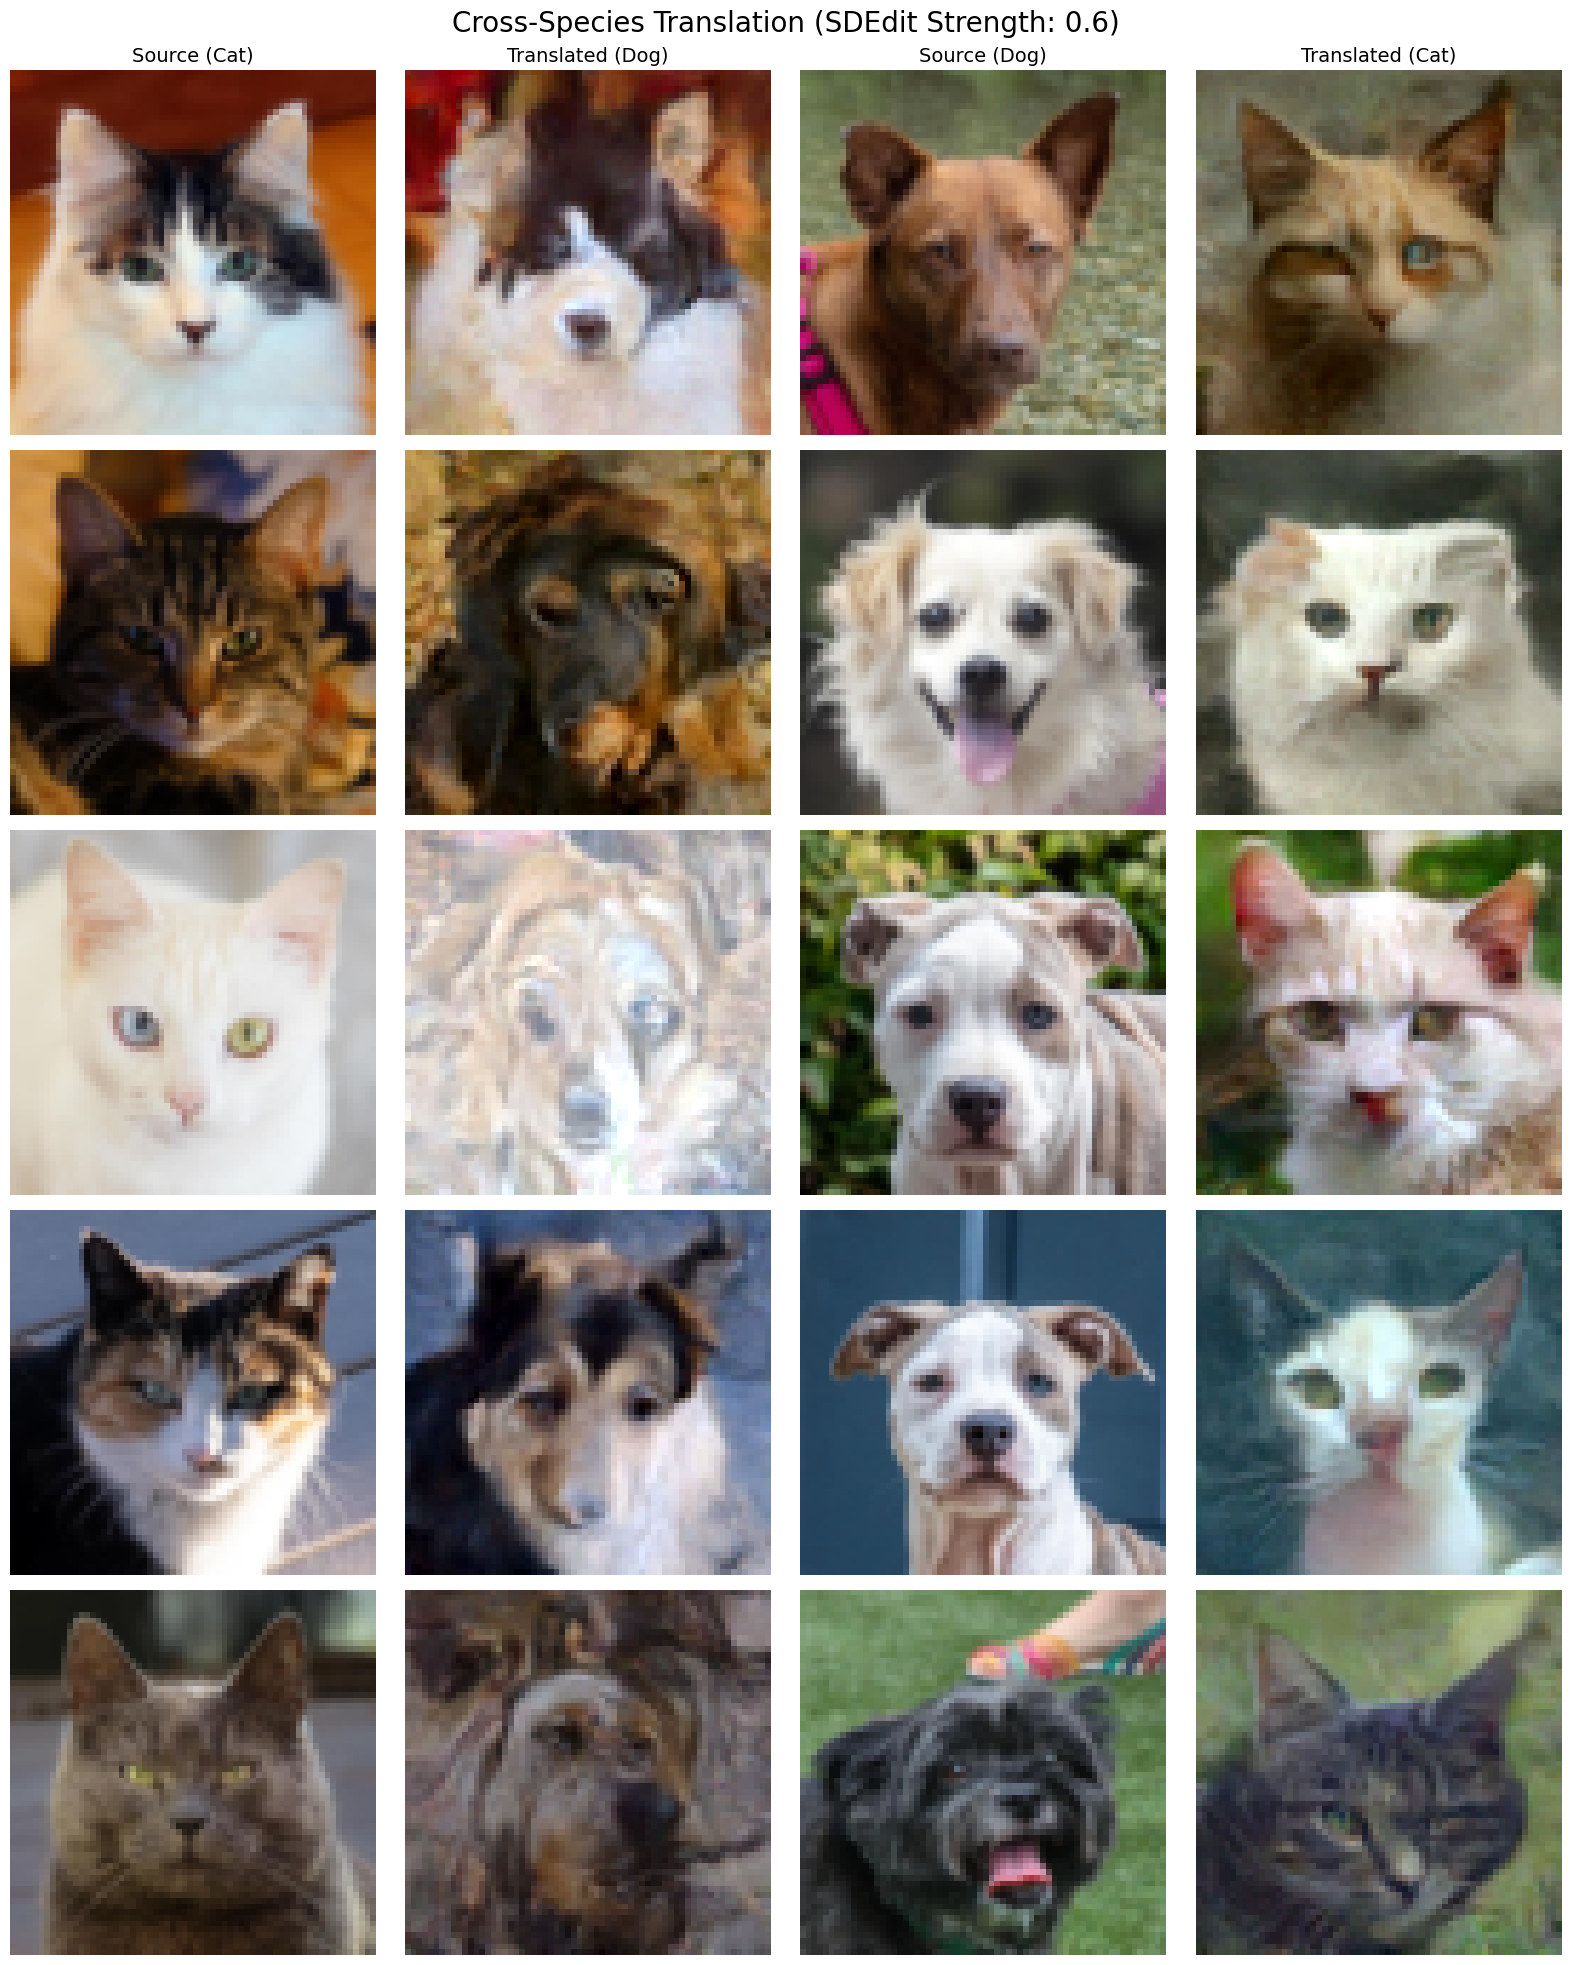

In [130]:
import matplotlib.pyplot as plt

STRENGTH = 0.6
diffusion_tools = Diffusion(noise_steps=1000, img_size=IMG_SIZE, device=device, schedule="cosine")

# Find 5 Cats and 5 Dogs
cat_indices = []
dog_indices = []

for i in range(len(val_loader.dataset)):
    _, label = val_loader.dataset[i]
    if int(label) == 0 and len(cat_indices) < 5:
        cat_indices.append(i)
    elif int(label) == 1 and len(dog_indices) < 5:
        dog_indices.append(i)
    if len(cat_indices) >= 5 and len(dog_indices) >= 5:
        break

# Setup Visualization Grid
fig, axes = plt.subplots(5, 4, figsize=(16, 20))
fig.suptitle(f'Cross-Species Translation (SDEdit Strength: {STRENGTH})', fontsize=20)

axes[0, 0].set_title("Source (Cat)", fontsize=14)
axes[0, 1].set_title("Translated (Dog)", fontsize=14)
axes[0, 2].set_title("Source (Dog)", fontsize=14)
axes[0, 3].set_title("Translated (Cat)", fontsize=14)

# Process and Plot
for i in range(5):
    # Process Cat -> Dog
    cat_img, cat_lbl = val_loader.dataset[cat_indices[i]] # Range [-1, 1]
    cat_res = translate_species(ema.ema_model, diffusion_tools, cat_img, cat_lbl, clip_embeddings, strength=STRENGTH) # Range [0, 1]
    
    # Process Dog -> Cat
    dog_img, dog_lbl = val_loader.dataset[dog_indices[i]] # Range [-1, 1]
    dog_res = translate_species(ema.ema_model, diffusion_tools, dog_img, dog_lbl, clip_embeddings, strength=STRENGTH) # Range [0, 1]

    pairs = [
        (cat_img, True),
        (cat_res, False),
        (dog_img, True),
        (dog_res, False)
    ]
    
    for col, (tensor_img, is_loader_img) in enumerate(pairs):
        if tensor_img.ndim == 4:
            tensor_img = tensor_img.squeeze(0)
        
        img_cpu = tensor_img.permute(1, 2, 0).cpu()
        
        if is_loader_img:
            show_img = (img_cpu + 1) / 2
        else:
            show_img = img_cpu
            
        axes[i, col].imshow(show_img.clamp(0, 1))
        axes[i, col].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

### 7. Unconditional Generation (Stress Test)

While the primary goal of this study is image translation, we also implement a generate_from_scratch function to validate the quality of the learned latent space. Unlike the translation task which starts from a noisy image, this process initializes xT​ as pure Gaussian noise N(0,I).

We again utilize Classifier-Free Guidance, which is critical here to prevent "mode collapse" or generic, blurry outputs. By setting a high guidance scale (e.g., 10.0), we force the model to aggressively prioritize regions of the latent space that strongly align with the CLIP embeddings for "Cat" or "Dog," verifying that the model has internalized the distinct morphological features of each species rather than just memorizing texture patches.

In [121]:
import matplotlib.pyplot as plt

def generate_from_scratch(model, diffusion, class_label=0, clip_embeddings=None, guidance_scale=7.0, n_images=4):
    model.eval()
    with torch.no_grad():
        # Start from Pure Random Noise
        x = torch.randn((n_images, 3, diffusion.img_size, diffusion.img_size)).to(device)
        
        # Get CLIP embedding for target class
        target_clip_emb = F.normalize(
            clip_embeddings[class_label].unsqueeze(0).expand(n_images, -1).to(model.device),
            dim=-1
        )
        
        # 2. Denoise loop with classifier-free guidance
        for i in reversed(range(1, diffusion.noise_steps)):
            t = torch.ones(n_images).long().to(device) * i
            
            # Predict with conditioning
            predicted_noise_cond = model(x, t, target_clip_emb)
            
            # Predict without conditioning
            null_emb = torch.zeros_like(target_clip_emb)
            predicted_noise_uncond = model(x, t, null_emb)
            
            # Combine with guidance
            predicted_noise = predicted_noise_uncond + guidance_scale * (predicted_noise_cond - predicted_noise_uncond)
            
            alpha = diffusion.alpha[t][:, None, None, None]
            alpha_hat = diffusion.alpha_hat[t][:, None, None, None]
            beta = diffusion.beta[t][:, None, None, None]
            
            if i > 1:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)
                
            x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
            x = torch.clamp(x, -1.0, 1.0)
    x = (x.clamp(-1, 1) + 1) / 2
    return x

diff_debug = Diffusion(img_size=IMG_SIZE, device=device, schedule="cosine")

Attempting to generate 5 Dogs from scratch


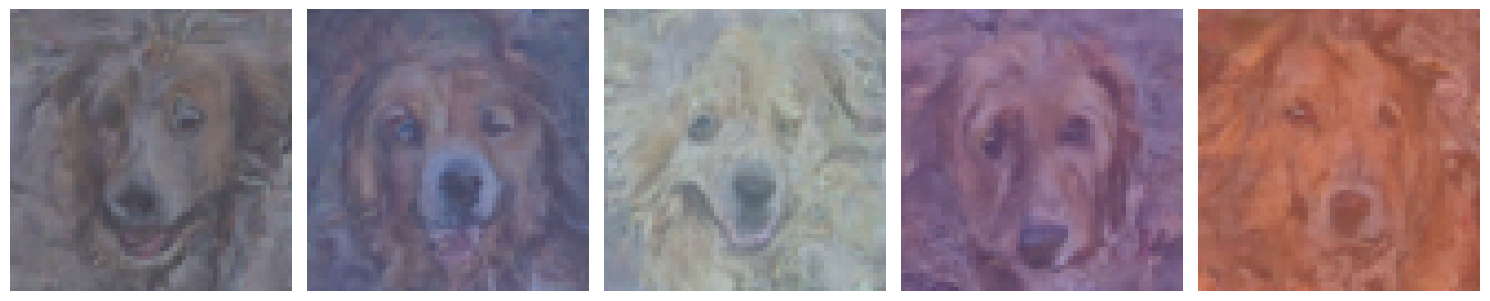

In [122]:
# Generate 5 Dogs
print("Attempting to generate 5 Dogs from scratch")
gen_imgs = generate_from_scratch(ema.ema_model, diff_debug, class_label=1, clip_embeddings=clip_embeddings, n_images=5)

plt.figure(figsize=(15, 5))
for i in range(len(gen_imgs)):
    plt.subplot(1, 5, i+1)
    
    img = gen_imgs[i].detach().cpu()
    img = img.permute(1, 2, 0)
    
    plt.imshow(img.clamp(0, 1))
    plt.axis('off')
    
plt.tight_layout()
plt.show()


Attempting to generate 5 Cats from scratch


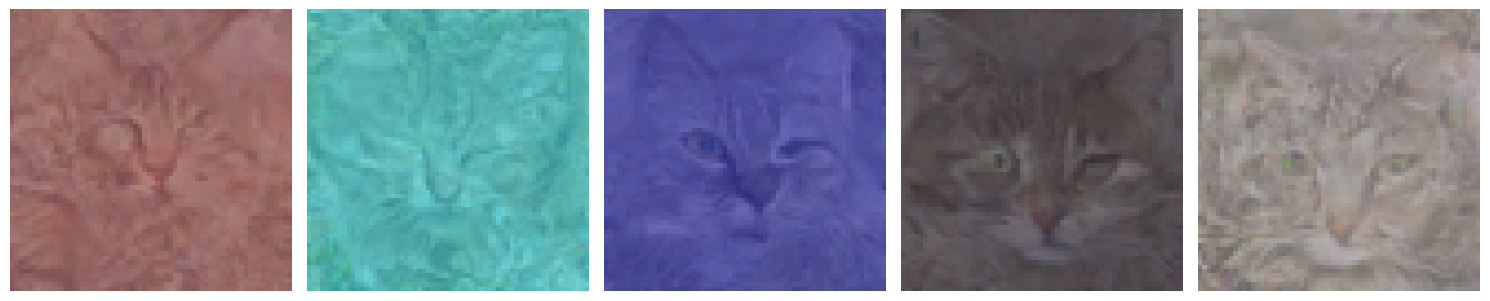

In [123]:
# Generate 5 Cats
print("Attempting to generate 5 Cats from scratch")
gen_imgs = generate_from_scratch(ema.ema_model, diff_debug, class_label=0, clip_embeddings=clip_embeddings, n_images=5)

plt.figure(figsize=(15, 5))
for i in range(len(gen_imgs)):
    plt.subplot(1, 5, i+1)
    
    img = gen_imgs[i].detach().cpu()
    img = img.permute(1, 2, 0)
    
    plt.imshow(img.clamp(0, 1))
    plt.axis('off')
    
plt.tight_layout()
plt.show()


#### References:
***
1. Jonathan Ho and Ajay Jain and Pieter Abbeel "Denoising Diffusion Probabilistic Models" [https://arxiv.org/pdf/2006.11239]
2. https://medium.com/data-science/diffusion-model-from-scratch-in-pytorch-ddpm-9d9760528946

#### Tools used:
***
1. Visual Studio Code
2. Google Gemini 2.5
3. Git (versioning)

#### GitHub link:
***
https://github.com/robertbejan/deepavance/tree/main